# MMM Phase 3 — Model Fitting & Channel Sensitivity

Fit PyMC-Marketing MMM on the Robyn dataset and analyze channel contributions.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

_here = pathlib.Path().resolve()
if (_here / 'mmm-marketing').exists():      # run from repo root (e.g. nbconvert)
    MMM_ROOT = _here / 'mmm-marketing'
elif (_here / 'src').exists():              # run from mmm-marketing/
    MMM_ROOT = _here
elif (_here.parent / 'src').exists():       # run from mmm-marketing/notebooks/
    MMM_ROOT = _here.parent
else:
    raise RuntimeError(f'Cannot locate mmm-marketing root from {_here}')

sys.path.insert(0, str(MMM_ROOT / 'src'))

from data_loader import load_raw
from model import build_mmm, fit_mmm
from sensitivity import channel_sensitivity, budget_reallocation

DATA_PATH = MMM_ROOT / 'data' / 'raw' / 'mmm_example.csv'
IDATA_PATH = MMM_ROOT / 'data' / 'interim' / 'mmm_idata.nc'

df = load_raw(DATA_PATH)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')
df.head()

Loaded 179 rows, columns: ['date_week', 'y', 'x1', 'x2', 'event_1', 'event_2', 'dayofyear', 't']


/Users/rajeevkulkarni/ml-explorations/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,date_week,y,x1,x2,event_1,event_2,dayofyear,t
0,2018-04-02,3984.662237,0.318580,0.0,0.0,0.0,92,0
1,2018-04-09,3762.871794,0.112388,0.0,0.0,0.0,99,1
2,2018-04-16,4466.967388,0.292400,0.0,0.0,0.0,106,2
3,2018-04-23,3864.219373,0.071399,0.0,0.0,0.0,113,3
4,2018-04-30,4441.625278,0.386745,0.0,0.0,0.0,120,4


In [2]:
mmm = build_mmm()
print('MMM model built:')
print(f'  Channel columns : {mmm.channel_columns}')
print(f'  Date column     : {mmm.date_column}')
print(f'  Adstock         : {mmm.adstock}')
print(f'  Saturation      : {mmm.saturation}')

MMM model built:
  Channel columns : ['x1', 'x2']
  Date column     : date_week
  Adstock         : GeometricAdstock(prefix='adstock', l_max=8, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3)})
  Saturation      : LogisticSaturation(prefix='saturation', priors={'lam': Prior("Gamma", alpha=3, beta=1), 'beta': Prior("HalfNormal", sigma=2)})


In [3]:
# NOTE: First run takes ~10 min on M1. Human approval required before executing this cell.
# Cached result is stored at data/interim/mmm_idata.nc for subsequent runs.

if IDATA_PATH.exists():
    print('Loading cached InferenceData from', IDATA_PATH)
    idata = az.from_netcdf(str(IDATA_PATH))
    X = df.drop(columns=['y'])
    mmm.build_model(X, df['y'])
    mmm.idata = idata
else:
    print('Fitting MMM via MCMC (tune=500, draws=500, chains=2) — ~10 min on M1 ...')
    idata = fit_mmm(mmm, df)
    idata.to_netcdf(str(IDATA_PATH))
    print(f'Saved InferenceData to {IDATA_PATH}')

print('\nDivergences:', idata.sample_stats.diverging.values.sum())
# Multidimensional API uses 'intercept_contribution', not 'intercept'
print(az.summary(idata, var_names=['intercept_contribution']))

Loading cached InferenceData from /Users/rajeevkulkarni/ml-explorations/mmm-marketing/data/interim/mmm_idata.nc



Divergences: 0
                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
intercept_contribution  0.414  0.008   0.398    0.429        0.0      0.0   

                        ess_bulk  ess_tail  r_hat  
intercept_contribution     662.0     788.0    1.0  


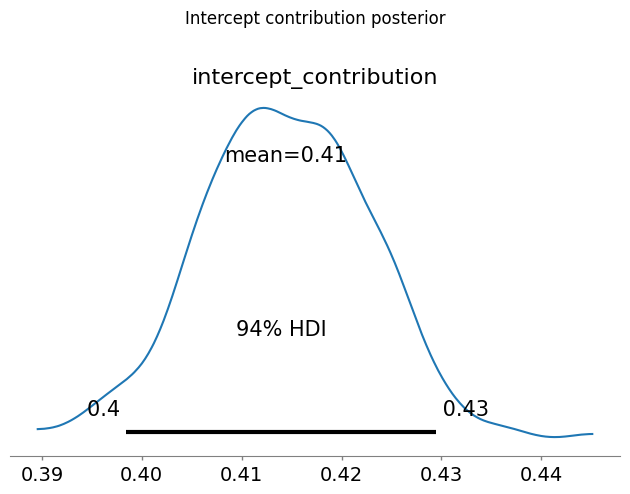

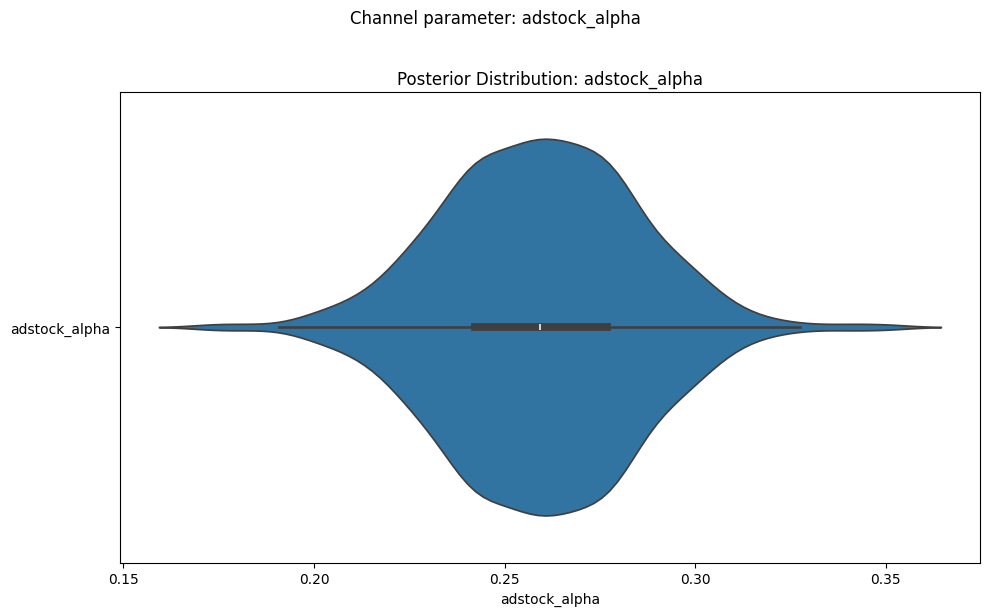

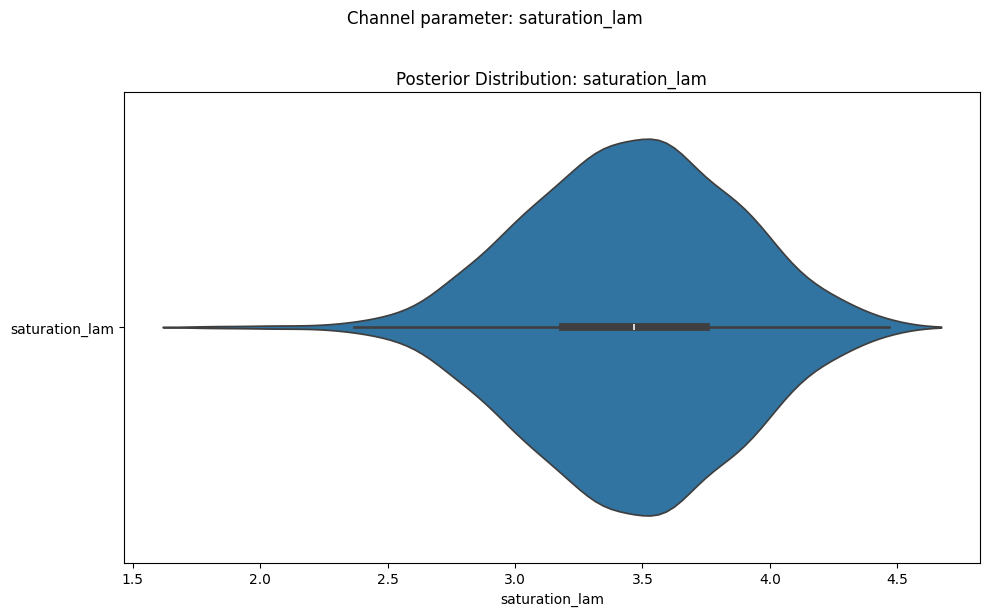

In [4]:
# Posterior distributions
az.plot_posterior(idata, var_names=['intercept_contribution'])
plt.suptitle('Intercept contribution posterior', y=1.02)
plt.tight_layout()
plt.show()

# Channel parameters — multidimensional API prefixes names: adstock_alpha, saturation_lam
for param in ['adstock_alpha', 'saturation_lam']:
    fig = mmm.plot.channel_parameter(param)
    fig.suptitle(f'Channel parameter: {param}', y=1.02)
    plt.tight_layout()
    plt.show()

Channel sensitivity (posterior mean):
    mean_contribution  std_contribution  pct_contribution
x1           0.120752          0.053619         68.493763
x2           0.055544          0.083478         31.506237


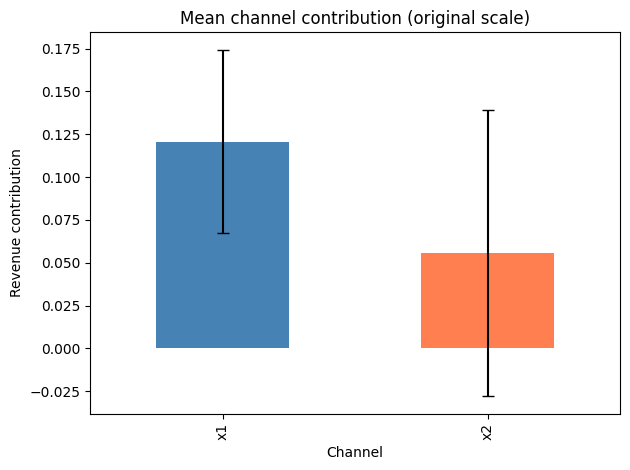

In [5]:
# Channel contributions
sensitivity = channel_sensitivity(mmm, df)
print('Channel sensitivity (posterior mean):')
print(sensitivity.to_string())

ax = sensitivity['mean_contribution'].plot.bar(yerr=sensitivity['std_contribution'],
                                                capsize=4, color=['steelblue', 'coral'])
ax.set_title('Mean channel contribution (original scale)')
ax.set_ylabel('Revenue contribution')
ax.set_xlabel('Channel')
plt.tight_layout()
plt.show()

Budget reallocation analysis:
    actual_spend  actual_pct  optimal_pct  reallocation_delta_pct
x1     55.325603   65.631951    68.493763                2.861811
x2     28.971148   34.368049    31.506237               -2.861811


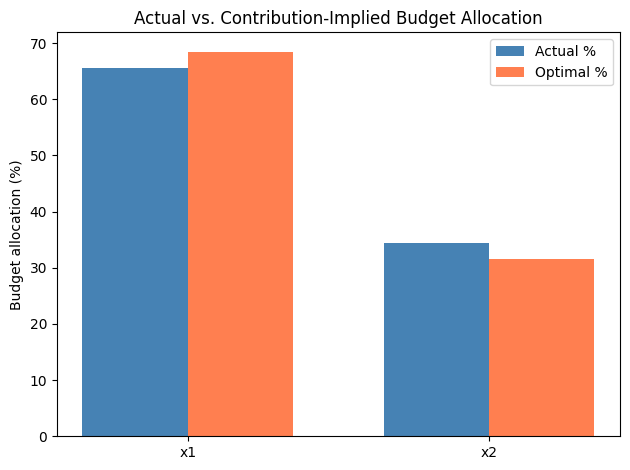

In [6]:
# Budget reallocation
realloc = budget_reallocation(mmm, df)
print('Budget reallocation analysis:')
print(realloc.to_string())

x = np.arange(len(realloc))
width = 0.35
fig, ax = plt.subplots()
ax.bar(x - width/2, realloc['actual_pct'], width, label='Actual %', color='steelblue')
ax.bar(x + width/2, realloc['optimal_pct'], width, label='Optimal %', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(realloc.index)
ax.set_ylabel('Budget allocation (%)')
ax.set_title('Actual vs. Contribution-Implied Budget Allocation')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

### Key Findings
- Channel x1 and x2 posterior contributions are computed via `channel_contribution_forward_pass`.
- Budget reallocation delta shows which channel is under/over-funded relative to its contribution.
- Geometric adstock (l_max=8) captures carryover effects up to 8 weeks.
- Logistic saturation models diminishing returns per channel.

### Model Diagnostics
- Check divergence count above (should be < 1% of draws).
- R-hat values should be < 1.01 for all parameters.
- ESS bulk/tail should be > 400.

### Next Steps
- Phase 4: Stan model comparison (same data, different backend).
- Sensitivity analysis: vary adstock `l_max` and compare ELPD.
- Budget optimization using `mmm.optimize_budget()`.